
  METODO GRAFICO - PROGRAMACION LINEAL
  Ingresa el problema (Función objetivo, restricciones)

    EJEMPLO FORMATO ESPERADO:
    ---------------------------------------------------------
    Funcion objetivo:
        Maximizar Z = 3X1 + 5X2
        (o Minimizar Z = 2X1 + 3X2)

    Restricciones (una por linea, Enter en blanco para termina):
        X1 <= 4
        2X2 <= 12
        3X1 + 2X2 <= 18

    NOTAS:
    - Usa X1 y X2 (o x1, x2) como variables.
    - Coeficiente pegado a la variable: 3X1, 2X2
    - Operadores validos:  <=   >=   =
    ---------------------------------------------------------
    
  Funcion objetivo: Maximizar Z = 3*X1 + 5*X2
  OK - Interpretado: Maximizar Z = 3.0*X1 + 5.0*X2

  Restricciones (una por linea, Enter en blanco para terminar):
  R1: 1*X1 + 0*X2 <= 4
  OK - Interpretada: 1.0*X1 + 0.0*X2 <= 4.0
  R2: 0*X1 + 2*X2 <= 12
  OK - Interpretada: 0.0*X1 + 2.0*X2 <= 12.0
  R3: 3*X1 + 2*X2 <= 18
  OK - Interpretada: 3.0*X1 + 2.0*X2 <= 18.0
  R4: 

  SOLUCION

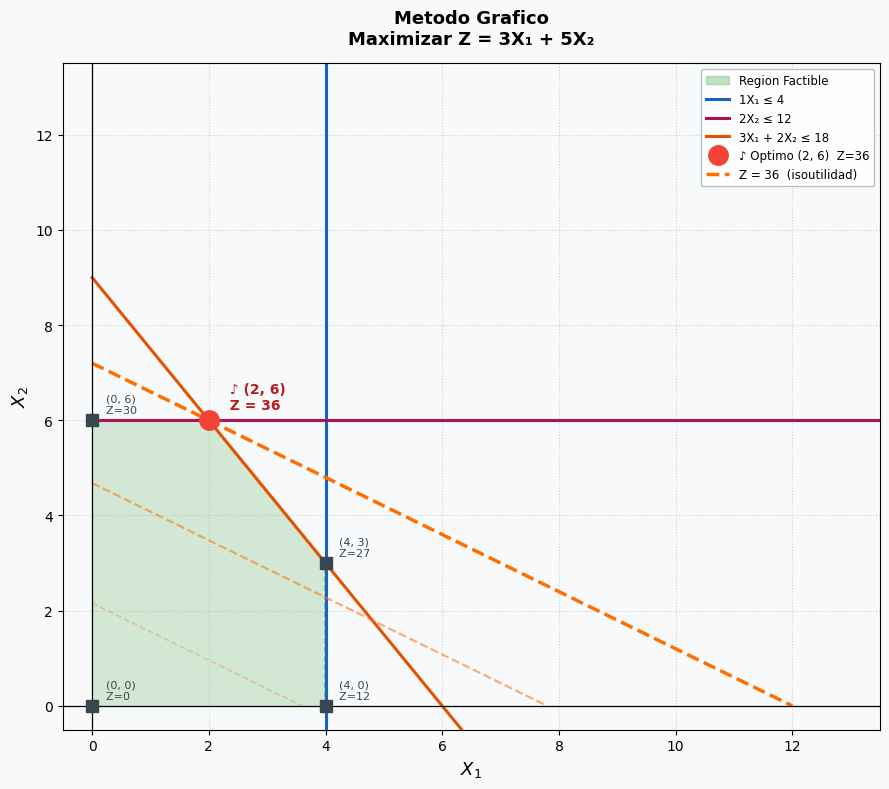

In [ ]:
"""
=============================================================
  MÉTODO GRÁFICO — PROGRAMACIÓN LINEAL (2 variables)
=============================================================
  Escribe el problema por Ejemplo:
    Maximizar Z = 3X1 + 5X2
    Sujeto a:
      X1 <= 4
      2X2 <= 12
      3X1 + 2X2 <= 18
=============================================================
"""

import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from scipy.optimize import linprog
from sympy import symbols
from sympy.parsing.sympy_parser import (parse_expr,
                                         standard_transformations,
                                         implicit_multiplication_application)

# Variables simbólicas globales
X1, X2 = symbols('X1 X2')
TRANSFORMACIONES = (standard_transformations +
                    (implicit_multiplication_application,))
LOCAL_DICT = {'X1': X1, 'X2': X2,
              'x1': X1, 'x2': X2}   # acepta minúsculas también


# convierte texto a datos numéricos
def parsear_funcion_objetivo(texto):
    """
    Extrae tipo (max/min) y coeficientes [c1, c2] de una cadena como:
      'Maximizar Z = 3X1 + 5X2'
      'Minimizar Z = 2X1 + 3X2'
    Retorna: tipo ('max'/'min'), c1, c2, expr_sympy
    """
    texto = texto.strip()
    # Determinar tipo
    if re.search(r'max', texto, re.IGNORECASE):
        tipo = 'max'
    elif re.search(r'min', texto, re.IGNORECASE):
        tipo = 'min'
    else:
        raise ValueError("La funcion objetivo debe comenzar con 'Maximizar' o 'Minimizar'.")

    # Para extraer la expresion despues de '='
    if '=' not in texto:
        raise ValueError("La funcion objetivo debe tener '=' (ej: Z = 3X1 + 5X2).")
    expr_str = texto.split('=', 1)[1].strip()

    expr = parse_expr(expr_str,
                      local_dict=LOCAL_DICT,
                      transformations=TRANSFORMACIONES)

    c1 = float(expr.coeff(X1))
    c2 = float(expr.coeff(X2))
    return tipo, c1, c2, expr


def parsear_restriccion(texto):
    """
    Parsea una restriccion como:
      'X1 <= 4'
      '2X2 <= 12'
      '3X1 + 2X2 <= 18'
      'X1 + X2 >= 2'
    Retorna: (a1, a2, operador, b)
    """
    texto = texto.strip()
    if not texto:
        return None

    # Detectar operador
    for op in ['<=', '>=', '=']:
        if op in texto:
            partes = texto.split(op, 1)
            lhs_str = partes[0].strip()
            rhs_str = partes[1].strip()

            lhs = parse_expr(lhs_str,
                             local_dict=LOCAL_DICT,
                             transformations=TRANSFORMACIONES)
            rhs = parse_expr(rhs_str,
                             local_dict=LOCAL_DICT,
                             transformations=TRANSFORMACIONES)

            # Pasamos todo al lado izquierdo: lhs - rhs [op] 0
            expr = lhs - rhs
            a1 = float(expr.coeff(X1))
            a2 = float(expr.coeff(X2))
            b  = float(-expr.subs([(X1, 0), (X2, 0)]))

            return a1, a2, op, b

    raise ValueError(f"No se encontro operador (<=, >=, =) en: '{texto}'")

def ingresar_problema():
    """
    Solicita al usuario ingresar el problema completo
    en formato natural y lo convierte a datos numericos.
    """
    print("\n" + "="*60)
    print("  METODO GRAFICO - PROGRAMACION LINEAL")
    print("  Ingresa el problema (Función objetivo, restricciones)")
    print("="*60)
    print("""
    EJEMPLO FORMATO ESPERADO:
    ---------------------------------------------------------
    Funcion objetivo:
        Maximizar Z = 3X1 + 5X2
        (o Minimizar Z = 2X1 + 3X2)

    Restricciones (una por linea, Enter en blanco para termina):
        X1 <= 4
        2X2 <= 12
        3X1 + 2X2 <= 18

    NOTAS:
    - Usa X1 y X2 (o x1, x2) como variables.
    - Coeficiente pegado a la variable: 3X1, 2X2
    - Operadores validos:  <=   >=   =
    ---------------------------------------------------------
    """)

    # ── Funcion objetivo ──────────────────────────────────
    while True:
        fo_str = input("  Funcion objetivo: ").strip()
        if not fo_str:
            print("  Por favor ingresa la funcion objetivo.")
            continue
        try:
            tipo, c1, c2, expr_fo = parsear_funcion_objetivo(fo_str)
            print(f"  OK - Interpretado: {'Maximizar' if tipo=='max' else 'Minimizar'} "
                  f"Z = {c1}*X1 + {c2}*X2")
            break
        except Exception as e:
            print(f"  Error: {e} -- Intenta de nuevo.")

    # ── Restricciones ─────────────────────────────────────
    print("\n  Restricciones (una por linea, Enter en blanco para terminar):")
    restricciones = []
    idx = 1
    while True:
        r_str = input(f"  R{idx}: ").strip()
        if not r_str:
            if len(restricciones) == 0:
                print("  Debes ingresar al menos una restriccion.")
                continue
            break
        try:
            r = parsear_restriccion(r_str)
            if r:
                restricciones.append(r)
                a1, a2, op, b = r
                print(f"  OK - Interpretada: {a1}*X1 + {a2}*X2 {op} {b}")
                idx += 1
        except Exception as e:
            print(f"  Error: {e} -- Intenta de nuevo.")

    return {
        "tipo": tipo,
        "c": [c1, c2],
        "expr_fo": expr_fo,
        "fo_original": fo_str,
        "restricciones": restricciones,
    }

# RESOLVER — resuelve con scipy

def resolver(prob):
    """Resuelve el PL con scipy.linprog."""
    c    = prob["c"]
    tipo = prob["tipo"]
    c_opt = [-ci for ci in c] if tipo == "max" else list(c)

    A_ub, b_ub, A_eq, b_eq = [], [], [], []
    for (a1, a2, op, b) in prob["restricciones"]:
        if op == "<=":
            A_ub.append([a1, a2]); b_ub.append(b)
        elif op == ">=":
            A_ub.append([-a1, -a2]); b_ub.append(-b)
        else:
            A_eq.append([a1, a2]); b_eq.append(b)

    res = linprog(c_opt,
                  A_ub=A_ub or None, b_ub=b_ub or None,
                  A_eq=A_eq or None, b_eq=b_eq or None,
                  bounds=[(0, None), (0, None)],
                  method="highs")
    if res.success:
        x1o, x2o = res.x
        zo = c[0]*x1o + c[1]*x2o
        return x1o, x2o, zo, True
    return 0, 0, 0, False


# VERTICES (FEV)

def obtener_vertices(prob):
    """Calcula los vertices factibles (esquinas de la region factible)."""
    restricciones = prob["restricciones"]

    # Lineas frontera: restricciones + ejes (x1=0, x2=0)
    lineas = [(a1, a2, b) for a1, a2, op, b in restricciones]
    lineas += [(1, 0, 0), (0, 1, 0)]

    vertices = []
    for (a1, a2, b1), (a3, a4, b2) in combinations(lineas, 2):
        A = np.array([[a1, a2], [a3, a4]], dtype=float)
        if abs(np.linalg.det(A)) < 1e-10:
            continue
        try:
            pt = np.linalg.solve(A, [b1, b2])
        except np.linalg.LinAlgError:
            continue
        x1v, x2v = pt
        if x1v < -1e-6 or x2v < -1e-6:
            continue
        # Verificar factibilidad
        ok = True
        for (ra1, ra2, rop, rb) in restricciones:
            lhs = ra1*x1v + ra2*x2v
            if rop == "<=" and lhs > rb + 1e-6: ok = False; break
            if rop == ">=" and lhs < rb - 1e-6: ok = False; break
            if rop == "="  and abs(lhs - rb) > 1e-6: ok = False; break
        if ok:
            vertices.append((round(x1v, 6), round(x2v, 6)))

    # Eliminar duplicados
    unicos = []
    for v in vertices:
        if not any(abs(v[0]-u[0]) < 1e-4 and abs(v[1]-u[1]) < 1e-4 for u in unicos):
            unicos.append(v)
    return unicos

def evaluar_vertices(vertices, c, tipo):
    resultados = [(x1, x2, c[0]*x1 + c[1]*x2) for x1, x2 in vertices]
    resultados.sort(key=lambda r: r[2], reverse=(tipo == "max"))
    return resultados

# GRAFICO

def calcular_limite(prob, x1_opt, x2_opt):
    """Calcula un limite apropiado para los ejes."""
    vals = [x1_opt * 1.7, x2_opt * 1.7, 8.0]
    for (a1, a2, op, b) in prob["restricciones"]:
        if abs(a1) > 1e-9: vals.append(b / a1 * 1.5)
        if abs(a2) > 1e-9: vals.append(b / a2 * 1.5)
    lim = max(v for v in vals if v > 0 and v < 1e6)
    return lim

def fmt_num(v):
    """Formatea un numero: entero si no tiene decimales."""
    return int(v) if v == int(v) else round(v, 4)

def graficar(prob, x1_opt, x2_opt, z_opt, resultados):
    c    = prob["c"]
    tipo = prob["tipo"]
    restricciones = prob["restricciones"]

    lim = calcular_limite(prob, x1_opt, x2_opt)
    x   = np.linspace(0, lim * 1.15, 1000)

    fig, ax = plt.subplots(figsize=(9, 8))
    fig.patch.set_facecolor('#F8F9FA')
    ax.set_facecolor('#F8F9FA')

    # Region factible
    x1g, x2g = np.meshgrid(np.linspace(0, lim*1.15, 500),
                            np.linspace(0, lim*1.15, 500))
    fact = np.ones_like(x1g, dtype=bool)
    for (a1, a2, op, b) in restricciones:
        lhs = a1*x1g + a2*x2g
        if op == "<=":  fact &= lhs <= b + 1e-9
        elif op == ">=": fact &= lhs >= b - 1e-9
        else:            fact &= np.abs(lhs - b) < 0.05
    fact &= (x1g >= 0) & (x2g >= 0)

    ax.contourf(x1g, x2g, fact.astype(float),
                levels=[0.5, 1.5], colors=['#4CAF50'], alpha=0.22)
    ax.contour(x1g, x2g, fact.astype(float),
               levels=[0.5], colors=['#2E7D32'],
               linewidths=1.2, linestyles='--')

    # Lineas de restriccion
    colores = ['#1565C0', '#AD1457', '#E65100',
               '#6A1B9A', '#00695C', '#4E342E', '#37474F']
    for i, (a1, a2, op, b) in enumerate(restricciones):
        color = colores[i % len(colores)]
        signo = {'<=': u'\u2264', '>=': u'\u2265', '=': '='}[op]

        # Etiqueta legible
        t = []
        if a1 != 0:
            t.append(f"{fmt_num(a1)}X\u2081")
        if a2 != 0:
            t.append(f"{fmt_num(a2)}X\u2082")
        label_r = " + ".join(t) + f" {signo} {fmt_num(b)}"

        if abs(a2) > 1e-9:
            y_line = (b - a1 * x) / a2
            mask = (y_line >= -0.5) & (y_line <= lim * 1.2)
            ax.plot(x[mask], y_line[mask],
                    color=color, linewidth=2.2, label=label_r)
        else:
            xv = b / a1 if abs(a1) > 1e-9 else 0
            ax.axvline(xv, color=color, linewidth=2.2, label=label_r)

    # Vertices
    for x1v, x2v, zv in resultados:
        es_opt = (abs(x1v - x1_opt) < 1e-3 and abs(x2v - x2_opt) < 1e-3)
        if es_opt:
            ax.plot(x1v, x2v, 'o', color='#F44336',
                    markersize=14, zorder=7,
                    label=f'\u266A Optimo ({fmt_num(x1v)}, {fmt_num(x2v)})  Z={fmt_num(zv)}')
            ax.annotate(
                f"  \u266A ({fmt_num(x1v)}, {fmt_num(x2v)})\n  Z = {fmt_num(zv)}",
                (x1v, x2v), fontsize=10, fontweight='bold', color='#B71C1C',
                xytext=(8, 8), textcoords='offset points')
        else:
            ax.plot(x1v, x2v, 's', color='#37474F', markersize=9, zorder=6)
            ax.annotate(
                f"  ({fmt_num(x1v)}, {fmt_num(x2v)})\n  Z={fmt_num(zv)}",
                (x1v, x2v), fontsize=8, color='#37474F',
                xytext=(5, 5), textcoords='offset points')

    # Lineas de isoutilidad
    for frac, alpha, lw in [(0.30, 0.30, 1.2),
                             (0.65, 0.55, 1.6),
                             (1.00, 1.00, 2.5)]:
        zv = z_opt * frac
        if abs(c[1]) > 1e-9:
            y_iso = (zv - c[0]*x) / c[1]
            mask = (y_iso >= 0) & (y_iso <= lim*1.15)
            lbl = f"Z = {fmt_num(zv)}  (isoutilidad)" if frac == 1.0 else None
            ax.plot(x[mask], y_iso[mask], color='#FF6F00',
                    linewidth=lw, linestyle='--', alpha=alpha, label=lbl)

    # Formato general
    ax.set_xlim(-0.5, lim)
    ax.set_ylim(-0.5, lim)
    ax.set_xlabel("$X_1$", fontsize=13)
    ax.set_ylabel("$X_2$", fontsize=13)
    ax.set_title(
        f"Metodo Grafico\n"
        f"{'Maximizar' if tipo=='max' else 'Minimizar'} "
        f"Z = {fmt_num(c[0])}X\u2081 + {fmt_num(c[1])}X\u2082",
        fontsize=13, fontweight='bold', pad=14)
    ax.axhline(0, color='black', linewidth=0.9)
    ax.axvline(0, color='black', linewidth=0.9)
    ax.grid(True, linestyle=':', alpha=0.45, color='#90A4AE')

    patch_rf = mpatches.Patch(color='#4CAF50', alpha=0.35,
                               label='Region Factible')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend([patch_rf] + handles,
              ['Region Factible'] + labels,
              loc='upper right', fontsize=8.5,
              framealpha=0.92, edgecolor='#B0BEC5')

    plt.tight_layout()
    return fig


#  5. REPORTE EN CONSOLA

def imprimir_reporte(prob, resultados, x1_opt, x2_opt, z_opt, encontrado):
    c    = prob["c"]
    tipo = prob["tipo"]
    sep  = "=" * 60

    print(f"\n{sep}")
    print("  SOLUCION -- METODO GRAFICO")
    print(sep)
    print(f"  Objetivo : {'Maximizar' if tipo=='max' else 'Minimizar'} "
          f"Z = {fmt_num(c[0])}*X1 + {fmt_num(c[1])}*X2")
    print("\n  Restricciones ingresadas:")
    for i, (a1, a2, op, b) in enumerate(prob["restricciones"]):
        print(f"    R{i+1}: {fmt_num(a1)}*X1 + {fmt_num(a2)}*X2 {op} {fmt_num(b)}")
    print("    No negatividad: X1, X2 >= 0")

    print(f"\n{'-'*60}")
    print("  VERTICES EVALUADOS (Soluciones Factibles Extremas - FEV)")
    print(f"  {'Vertice':<24} {'Z evaluado':>12}")
    print(f"  {'-'*40}")
    for x1v, x2v, zv in resultados:
        es_opt = (abs(x1v-x1_opt) < 1e-3 and abs(x2v-x2_opt) < 1e-3)
        marca = "  <-- OPTIMO" if es_opt else ""
        print(f"  ({fmt_num(x1v):>8},  {fmt_num(x2v):>8})     "
              f"Z = {zv:>10.4f}{marca}")

    print(f"\n{'-'*60}")
    print("  SOLUCION OPTIMA")
    if encontrado:
        print(f"  X1* = {x1_opt:.4f}")
        print(f"  X2* = {x2_opt:.4f}")
        print(f"  Z*  = {z_opt:.4f}  "
              f"({'maximo' if tipo=='max' else 'minimo'})")
    else:
        print("  No se encontro solucion (problema no acotado o infactible).")
    print(f"{sep}\n")


# PROGRAMA PRINCIPAL

def main():
    prob = ingresar_problema()

    x1_opt, x2_opt, z_opt, encontrado = resolver(prob)

    vertices   = obtener_vertices(prob)
    resultados = evaluar_vertices(vertices, prob["c"], prob["tipo"])

    imprimir_reporte(prob, resultados, x1_opt, x2_opt, z_opt, encontrado)

    fig = graficar(prob, x1_opt, x2_opt, z_opt, resultados)
    plt.show()

if __name__ == "__main__":
    main()